# Credit Risk Assessment — Ensemble Learning + ACOR Weight Optimisation

**Pipeline Overview**
1. Data ingestion & quality checks
2. Train / Validation / Test split + SMOTENC oversampling
3. Preprocessing (StandardScaler + OneHotEncoder)
4. Train **7 diverse base models** + OOF cross-validation
5. **Automatic model selection** — keep best `k` models by OOF AUC
6. **ACOR** (Ant Colony Optimisation for Continuous Domains) to find optimal ensemble weights
7. QP benchmark for weight comparison
8. Final evaluation on the held-out test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
print('Core imports OK')

Core imports OK


## 1  Fetch & Inspect Data

In [2]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data
y = data.target.map({'good': 0, 'bad': 1})

print(f'Shape: {X.shape}')
X.head()

Shape: (1000, 20)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


In [3]:
dataset = pd.concat([X, y], axis=1)

print('=== Missing values ===')
print(X.isnull().sum())
print(f'\nDuplicated rows: {X.duplicated().sum()}')
print(f'\nClass distribution (%):')
print(dataset['class'].value_counts(normalize=True).mul(100).round(1))

=== Missing values ===
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
dtype: int64

Duplicated rows: 0

Class distribution (%):
class
0    70.0
1    30.0
Name: proportion, dtype: float64


## 2  Train / Validation / Test Split + SMOTENC

| Split | Size | Purpose |
|---|---|---|
| **Train** | 60 % | Fit base models (after SMOTENC) |
| **Validation** | 20 % | ACOR weight search + QP benchmark |
| **Test** | 20 % | Final untouched evaluation |

In [22]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = X.select_dtypes(include=['int64','float64','number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['category','object']).columns.tolist()
cat_indices = [X.columns.get_loc(col) for col in categorical_cols]
print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

# ── First split: peel off the test set ──
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# ── Second split: carve out the validation set ──
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# ── SMOTENC on training data only ──
sm = SMOTENC(categorical_features=cat_indices, sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_raw, y_train_raw)
X_train_res = pd.DataFrame(X_train_res, columns=X.columns)

# ── Preprocessing pipeline ──
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False),categorical_cols )
    ], remainder='passthrough'
)
preprocessor.set_output(transform='pandas')

X_train = preprocessor.fit_transform(X_train_res)
X_val   = preprocessor.transform(X_val)
X_test  = preprocessor.transform(X_test)
y_train = y_train_res

X_train.columns = X_train.columns.str.replace(r"[^A-Za-z0-9_]", "", regex=True)
X_val.columns   = X_val.columns.str.replace(r"[^A-Za-z0-9_]", "", regex=True)
X_test.columns  = X_test.columns.str.replace(r"[^A-Za-z0-9_]", "", regex=True)
print(f'\nDataset partitioned:')
print(f'  Train  (SMOTENC) : X={X_train.shape}, bad_rate={y_train.astype(int).mean():.3f}')
print(f'  Val               : X={X_val.shape},   bad_rate={y_val.astype(int).mean():.3f}')
print(f'  Test              : X={X_test.shape},   bad_rate={y_test.astype(int).mean():.3f}')

Numerical (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Dataset partitioned:
  Train  (SMOTENC) : X=(840, 48), bad_rate=0.500
  Val               : X=(200, 48),   bad_rate=0.300
  Test              : X=(200, 48),   bad_rate=0.300


['checking_status',
 'duration',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_status',
 'employment',
 'installment_commitment',
 'personal_status',
 'other_parties',
 'residence_since',
 'property_magnitude',
 'age',
 'other_payment_plans',
 'housing',
 'existing_credits',
 'job',
 'num_dependents',
 'own_telephone',
 'foreign_worker']

## 3  Base Model Zoo

Seven diverse classifiers are trained.  After 5-fold OOF cross-validation on the training set the **top `k` models** (ranked by OOF AUC) are automatically selected to form the ensemble.  Diversity across algorithmic families avoids ensemble corellation.

| # | Model | Key strength |
|---|---|---|
| 1 | Logistic Regression | Linear baseline, fast |
| 2 | SVM (RBF) | Margin maximiser, robust |
| 3 | MLP | Non-linear representations |
| 4 | Random Forest | Bagging, low variance |
| 5 | Gradient Boosted Trees (sklearn) | Boosting, sequential correction |
| 6 | XGBoost | Speed + regularisation |
| 7 | LightGBM | Leaf-wise boosting, large data |

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

base_models = {
    'Logistic_Regression' : LogisticRegression(max_iter=1000, C=0.5, random_state=42),
    'SVM'                 : SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'MLP'                 : MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          solver='adam', max_iter=500, random_state=42),
    'Random_Forest'       : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                    min_samples_leaf=5, random_state=42),
    'GBT'                 : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=42, verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                            random_state=42, verbose=-1),
}
print(f'{len(base_models)} base models initialised.')

7 base models initialised.


## 4  OOF Cross-Validation & Model Selection

Each model generates **Out-of-Fold (OOF)** probability predictions on the training set using Stratified 5-Fold CV.  These are used to:
- Rank models by OOF AUC (unbiased estimate of generalisation)
- Automatically select the **top `k` models** (default `k=5`) for the ensemble

> **Why OOF?**  Evaluating on the same data used to train inflates scores.  OOF predictions are analogous to leave-one-group-out cross-validation and give an honest signal.

In [23]:
from sklearn.model_selection import StratifiedKFold

K = 5
TOP_K = 5   # ← change to select more / fewer models for the ensemble
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))
oof_aucs = {}

print(f'Running {K}-Fold OOF CV on {N_train} training samples...\n')

for i, (name, model) in enumerate(base_models.items()):
    oof_preds = np.zeros(N_train)
    for train_idx, val_idx in skf.split(X_train, y_train):
        Xf_tr = X_train.iloc[train_idx]; yf_tr = y_train.iloc[train_idx]
        Xf_val = X_train.iloc[val_idx]
       
        model.fit(Xf_tr, yf_tr)
        oof_preds[val_idx] = model.predict_proba(Xf_val)[:, 1]
    oof_P_train[:, i] = oof_preds
    auc = roc_auc_score(y_train, oof_preds)
    oof_aucs[name] = auc
    print(f'  {name:<22} OOF AUC: {auc:.4f}')
    # Re-train on full training set
    model.fit(X_train, y_train)

print('\nAll base models retrained on full training set.')

Running 5-Fold OOF CV on 840 training samples...

  Logistic_Regression    OOF AUC: 0.8889
  SVM                    OOF AUC: 0.8951
  MLP                    OOF AUC: 0.8622
  Random_Forest          OOF AUC: 0.9005
  GBT                    OOF AUC: 0.8910
  XGBoost                OOF AUC: 0.8969
  LightGBM               OOF AUC: 0.8987

All base models retrained on full training set.


In [24]:
# ── Automatic model selection ──────────────────────────────────────────────
ranked = sorted(oof_aucs.items(), key=lambda x: x[1], reverse=True)
print(f'\n=== Ranked Model Performance (OOF AUC) ===')
for rank, (name, auc) in enumerate(ranked, 1):
    tag = '✓ SELECTED' if rank <= TOP_K else '  excluded'
    print(f'  {rank}. {name:<22} {auc:.4f}  {tag}')

selected_names = [name for name, _ in ranked[:TOP_K]]
selected_models = {n: base_models[n] for n in selected_names}
print(f'\nEnsemble will use {len(selected_models)} models: {selected_names}')


=== Ranked Model Performance (OOF AUC) ===
  1. Random_Forest          0.9005  ✓ SELECTED
  2. LightGBM               0.8987  ✓ SELECTED
  3. XGBoost                0.8969  ✓ SELECTED
  4. SVM                    0.8951  ✓ SELECTED
  5. GBT                    0.8910  ✓ SELECTED
  6. Logistic_Regression    0.8889    excluded
  7. MLP                    0.8622    excluded

Ensemble will use 5 models: ['Random_Forest', 'LightGBM', 'XGBoost', 'SVM', 'GBT']


## 5  Build Prediction Matrices  P_val  and  P_test

In [25]:
N_val  = X_val.shape[0]
N_test = X_test.shape[0]
M = len(selected_models)

P_val  = np.zeros((N_val,  M))
P_test = np.zeros((N_test, M))

for i, (name, model) in enumerate(selected_models.items()):
    P_val[:, i]  = model.predict_proba(X_val)[:, 1]
    P_test[:, i] = model.predict_proba(X_test)[:, 1]

y_val_arr  = y_val.values.astype(float)
y_test_arr = y_test.values.astype(float)

print(f'P_val  shape : {P_val.shape}')
print(f'P_test shape : {P_test.shape}')
print(f'\nSample P_val (first 3 rows):\n{np.round(P_val[:3], 4)}')

P_val  shape : (200, 5)
P_test shape : (200, 5)

Sample P_val (first 3 rows):
[[0.2665 0.1129 0.0947 0.0657 0.1014]
 [0.4607 0.3766 0.4468 0.242  0.3362]
 [0.0819 0.0217 0.0202 0.0113 0.0127]]


## 6  QP Benchmark — Optimal Weights via Quadratic Programming

We solve the exact QP problem:

$$\min_w \|\mathbf{P}\,w - y\|^2 \quad \text{s.t.}\; \sum w_i = 1,\; w_i \ge 0$$

using SciPy's SLSQP solver.  This gives the **mathematical global optimum** as a reference baseline for ACOR.

In [42]:
from scipy.optimize import minimize

def normalize_weights(w):
    """Enforce non-negativity and sum-to-one."""
    w_abs = np.abs(w)
    return w_abs / (np.sum(w_abs) + 1e-10)

def mse_objective(w, P, y):
    w_n = normalize_weights(w)
    return np.mean((P @ w_n - y) ** 2)

# QP matrices
Q = 2 * P_val.T @ P_val
c = (-2 * P_val.T @ y_val_arr.reshape(-1,1)).flatten()

def qp_obj(w, Q, c):
    return 0.5 * w @ Q @ w + c @ w

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
bounds = [(0.0, 1.0)] * M
w_init = np.ones(M) / M

qp_result = minimize(qp_obj, w_init, args=(Q, c), method='SLSQP',
                     bounds=bounds, constraints=constraints,
                     options={'disp': False, 'ftol': 1e-12})

w_QP = qp_result.x
mse_QP = np.mean((P_val @ w_QP - y_val_arr) ** 2)
auc_QP = roc_auc_score(y_val_arr, P_val @ w_QP)

print('QP Optimal Weights:')
for name, w in zip(selected_names, w_QP):
    print(f'  {name:<22} {w:.6f}')
print(f'\nQP Val MSE : {mse_QP:.6f}')
print(f'QP Val AUC : {auc_QP:.4f}')

QP Optimal Weights:
  Random_Forest          0.537310
  LightGBM               0.044511
  XGBoost                0.320829
  SVM                    0.097349
  GBT                    0.000000

QP Val MSE : 0.196492
QP Val AUC : 0.7283


## 7  ACOR — Ant Colony Optimisation for Continuous Domains

ACOR finds the optimal ensemble weights **without requiring a convex assumption** about the objective function — making it suitable for custom loss functions (e.g. AUC, F1, or domain-specific cost matrices) that SLSQP cannot handle directly.

**Key hyper-parameters**

| Parameter | Meaning | Typical range |
|---|---|---|
| `n_ants` | New solutions sampled per iteration | 20–100 |
| `archive_size` | Elite solution archive | 10–50 |
| `q` | Locality of selection (small = exploit best) | 0.01–0.5 |
| `xi` | Pheromone convergence speed | 0.5–1.0 |
| `iterations` | Total optimisation budget | 100–500 |

The objective can be freely swapped: **MSE** (default, directly comparable to QP) or **negative AUC** for rank-based optimisation.

In [43]:
from sklearn.metrics import log_loss

def run_acor(
    P, y,
    num_models,
    n_ants=50,
    archive_size=20,
    iterations=200,
    q=0.1,
    xi=0.85,
    objective='mse'   # 'mse' | 'logloss' | 'auc'
):
    """
    ACOR for ensemble weight optimisation.

    Parameters
    ----------
    P          : (N, M) prediction matrix
    y          : (N,)  ground-truth labels
    num_models : M  (number of base models)
    n_ants     : new candidate solutions per iteration
    archive_size : size of the elite solution archive
    iterations : total number of ACOR iterations
    q          : gaussian kernel locality parameter
    xi         : convergence speed (pheromone decay analogue)
    objective  : 'mse'     -> minimise Mean Squared Error
                 'logloss' -> minimise Binary Cross-Entropy  *** best for probabilistic scoring ***
                 'auc'     -> maximise ROC-AUC
    """

    def score(w):
        w_n = normalize_weights(w)
        preds = P @ w_n
        if objective == 'logloss':
            # Clip to avoid log(0); sklearn's log_loss also clips internally
            preds_clipped = np.clip(preds, 1e-7, 1 - 1e-7)
            return log_loss(y, preds_clipped)
        elif objective == 'auc':
            # Return negative AUC so that lower is better (consistent with MSE/logloss)
            try:
                return -roc_auc_score(y, preds)
            except Exception:
                return 0.0
        else:  # mse
            return np.mean((preds - y) ** 2)

    print(f'ACOR  |  {n_ants} ants  |  {archive_size} archive  |  {iterations} iterations  |  objective={objective}')

    # ── 1. Initialise solution archive with random uniform weights ──
    rng = np.random.default_rng(42)
    archive = rng.random((archive_size, num_models))
    archive = np.array([normalize_weights(w) for w in archive])
    scores  = np.array([score(w) for w in archive])

    idx = np.argsort(scores)
    archive, scores = archive[idx], scores[idx]

    # ── Rank-based Gaussian selection probabilities ──
    ranks = np.arange(1, archive_size + 1)
    raw_w = (1 / (q * archive_size * np.sqrt(2 * np.pi))) * \
             np.exp(-((ranks - 1) ** 2) / (2 * (q * archive_size) ** 2))
    sel_probs = raw_w / raw_w.sum()

    curve = np.zeros(iterations)

    # ── 2. Main optimisation loop ──
    for it in range(iterations):
        new_sols   = np.zeros((n_ants, num_models))
        new_scores = np.zeros(n_ants)

        for ant in range(n_ants):
            # Choose guiding solution from archive
            g = rng.choice(archive_size, p=sel_probs)
            guide = archive[g]

            # Dynamic sigma: proportional to archive spread around the guide
            sigma = xi * np.abs(archive - guide).sum(axis=0) / max(archive_size - 1, 1)
            sigma = np.maximum(sigma, 1e-6)  # prevent degenerate std

            # Sample & normalise
            w_new = rng.normal(loc=guide, scale=sigma)
            w_new = normalize_weights(w_new)
            new_sols[ant]   = w_new
            new_scores[ant] = score(w_new)

        # ── 3. Merge archive + new solutions, keep top archive_size ──
        merged_sols   = np.vstack((archive, new_sols))
        merged_scores = np.concatenate((scores, new_scores))

        top_idx = np.argsort(merged_scores)[:archive_size]
        archive, scores = merged_sols[top_idx], merged_scores[top_idx]

        curve[it] = scores[0]
        if (it + 1) % 50 == 0 or it == 0:
            metric_label = 'AUC' if objective == 'auc' else 'MSE'
            val = -scores[0] if objective == 'auc' else scores[0]
            print(f'  iter {it+1:4d}/{iterations}  best {metric_label}: {val:.6f}')

    best_w = normalize_weights(archive[0])
    return best_w, scores[0], curve

print('ACOR function defined.')

ACOR function defined.


In [44]:
from sklearn.metrics import log_loss

# ── ACOR: MSE objective (convex; should match QP closely) ──
w_ACO_mse, _, curve_mse = run_acor(
    P_val, y_val_arr, num_models=M,
    n_ants=50, archive_size=25, iterations=300,
    q=0.1, xi=0.85, objective='mse'
)
mse_ACO     = np.mean((P_val @ w_ACO_mse - y_val_arr) ** 2)
auc_ACO_mse = roc_auc_score(y_val_arr, P_val @ w_ACO_mse)
ll_ACO_mse  = log_loss(y_val_arr, np.clip(P_val @ w_ACO_mse, 1e-7, 1-1e-7))
ll_QP       = log_loss(y_val_arr, np.clip(P_val @ w_QP,      1e-7, 1-1e-7))

print(f'ACOR (MSE)   Val MSE={mse_ACO:.6f}  AUC={auc_ACO_mse:.4f}  LogLoss={ll_ACO_mse:.4f}')
print(f'QP benchmark Val MSE={mse_QP:.6f}  AUC={auc_QP:.4f}  LogLoss={ll_QP:.4f}')

ACOR  |  50 ants  |  25 archive  |  300 iterations  |  objective=mse
  iter    1/300  best MSE: 0.197041
  iter   50/300  best MSE: 0.196492
  iter  100/300  best MSE: 0.196492
  iter  150/300  best MSE: 0.196492
  iter  200/300  best MSE: 0.196492
  iter  250/300  best MSE: 0.196492
  iter  300/300  best MSE: 0.196492
ACOR (MSE)   Val MSE=0.196492  AUC=0.7283  LogLoss=0.5730
QP benchmark Val MSE=0.196492  AUC=0.7283  LogLoss=0.5730


In [45]:
# ── Run ACOR with AUC objective — maximise rank separation directly ──
w_ACO_ll, _, curve_ll = run_acor(
    P_val, y_val_arr, num_models=M,
    n_ants=50, archive_size=25, iterations=300,
    q=0.1, xi=0.85, objective='logloss'
)
mse_ACO_ll = np.mean((P_val @ w_ACO_ll - y_val_arr) ** 2)
auc_ACO_ll = roc_auc_score(y_val_arr, P_val @ w_ACO_ll)
ll_ACO_ll  = log_loss(y_val_arr, np.clip(P_val @ w_ACO_ll, 1e-7, 1-1e-7))

print(f'\nACOR (LogLoss) Val MSE={mse_ACO_ll:.6f}  AUC={auc_ACO_ll:.4f}  LogLoss={ll_ACO_ll:.4f}')

# ── ACOR: AUC objective — maximises rank separation ──
w_ACO_auc, _, curve_auc = run_acor(
    P_val, y_val_arr, num_models=M,
    n_ants=50, archive_size=25, iterations=300,
    q=0.1, xi=0.85, objective='auc'
)
mse_ACO_auc = np.mean((P_val @ w_ACO_auc - y_val_arr) ** 2)
auc_ACO_auc = roc_auc_score(y_val_arr, P_val @ w_ACO_auc)
ll_ACO_auc  = log_loss(y_val_arr, np.clip(P_val @ w_ACO_auc, 1e-7, 1-1e-7))

print(f'ACOR (AUC)     Val MSE={mse_ACO_auc:.6f}  AUC={auc_ACO_auc:.4f}  LogLoss={ll_ACO_auc:.4f}')

ACOR  |  50 ants  |  25 archive  |  300 iterations  |  objective=logloss
  iter    1/300  best MSE: 0.573634
  iter   50/300  best MSE: 0.572880
  iter  100/300  best MSE: 0.572880
  iter  150/300  best MSE: 0.572880
  iter  200/300  best MSE: 0.572880
  iter  250/300  best MSE: 0.572880
  iter  300/300  best MSE: 0.572880

ACOR (LogLoss) Val MSE=0.196537  AUC=0.7276  LogLoss=0.5729
ACOR  |  50 ants  |  25 archive  |  300 iterations  |  objective=auc
  iter    1/300  best AUC: 0.731429
  iter   50/300  best AUC: 0.734524
  iter  100/300  best AUC: 0.734524
  iter  150/300  best AUC: 0.734524
  iter  200/300  best AUC: 0.734524
  iter  250/300  best AUC: 0.734524
  iter  300/300  best AUC: 0.734524
ACOR (AUC)     Val MSE=0.200190  AUC=0.7345  LogLoss=0.5839


## 8  Weight Comparison & Convergence Visualisation

In [46]:
print('=== Ensemble Weight Comparison ===')
header = f'{"Model":<22} | {"QP":>8} | {"ACOR-MSE":>8} | {"ACOR-LL":>8} | {"ACOR-AUC":>8}'
print(header)
print('-' * len(header))
for i, name in enumerate(selected_names):
    print(f'{name:<22} | {w_QP[i]:>8.4f} | {w_ACO_mse[i]:>8.4f} | {w_ACO_ll[i]:>8.4f} | {w_ACO_auc[i]:>8.4f}')
print('-' * len(header))
print(f'{"Val MSE":<22} | {mse_QP:>8.5f} | {mse_ACO:>8.5f} | {mse_ACO_ll:>8.5f} | {mse_ACO_auc:>8.5f}')
print(f'{"Val AUC":<22} | {auc_QP:>8.4f} | {auc_ACO_mse:>8.4f} | {auc_ACO_ll:>8.4f} | {auc_ACO_auc:>8.4f}')
print(f'{"Val LogLoss":<22} | {ll_QP:>8.4f} | {ll_ACO_mse:>8.4f} | {ll_ACO_ll:>8.4f} | {ll_ACO_auc:>8.4f}')

print(f'\nL2 distance  QP vs ACOR-MSE : {np.linalg.norm(w_QP - w_ACO_mse):.6f}')
print(f'L2 distance  QP vs ACOR-LL  : {np.linalg.norm(w_QP - w_ACO_ll):.6f}')
print(f'L2 distance  QP vs ACOR-AUC : {np.linalg.norm(w_QP - w_ACO_auc):.6f}')

=== Ensemble Weight Comparison ===
Model                  |       QP | ACOR-MSE |  ACOR-LL | ACOR-AUC
------------------------------------------------------------------
Random_Forest          |   0.5373 |   0.5373 |   0.5074 |   0.1332
LightGBM               |   0.0445 |   0.0444 |   0.1071 |   0.0055
XGBoost                |   0.3208 |   0.3209 |   0.3031 |   0.6905
SVM                    |   0.0973 |   0.0973 |   0.0825 |   0.1682
GBT                    |   0.0000 |   0.0000 |   0.0000 |   0.0027
------------------------------------------------------------------
Val MSE                |  0.19649 |  0.19649 |  0.19654 |  0.20019
Val AUC                |   0.7283 |   0.7283 |   0.7276 |   0.7345
Val LogLoss            |   0.5730 |   0.5730 |   0.5729 |   0.5839

L2 distance  QP vs ACOR-MSE : 0.000095
L2 distance  QP vs ACOR-LL  : 0.073145
L2 distance  QP vs ACOR-AUC : 0.553663


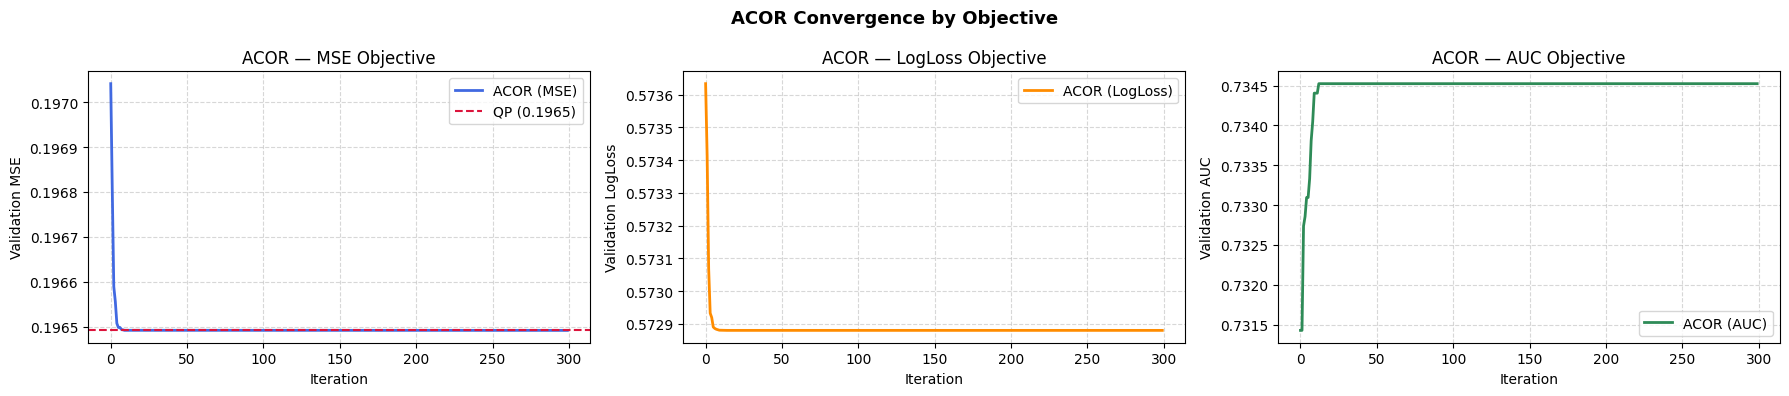

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# MSE convergence
axes[0].plot(curve_mse, color='royalblue', lw=2, label='ACOR (MSE)')
axes[0].axhline(mse_QP, color='crimson', lw=1.5, ls='--', label=f'QP ({mse_QP:.4f})')
axes[0].set_title('ACOR — MSE Objective'); axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Validation MSE'); axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.5)

# LogLoss convergence
axes[1].plot(curve_ll, color='darkorange', lw=2, label='ACOR (LogLoss)')
axes[1].set_title('ACOR — LogLoss Objective'); axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Validation LogLoss'); axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)

# AUC convergence
axes[2].plot(-curve_auc, color='seagreen', lw=2, label='ACOR (AUC)')
axes[2].set_title('ACOR — AUC Objective'); axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Validation AUC'); axes[2].legend(); axes[2].grid(True, ls='--', alpha=0.5)

plt.suptitle('ACOR Convergence by Objective', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

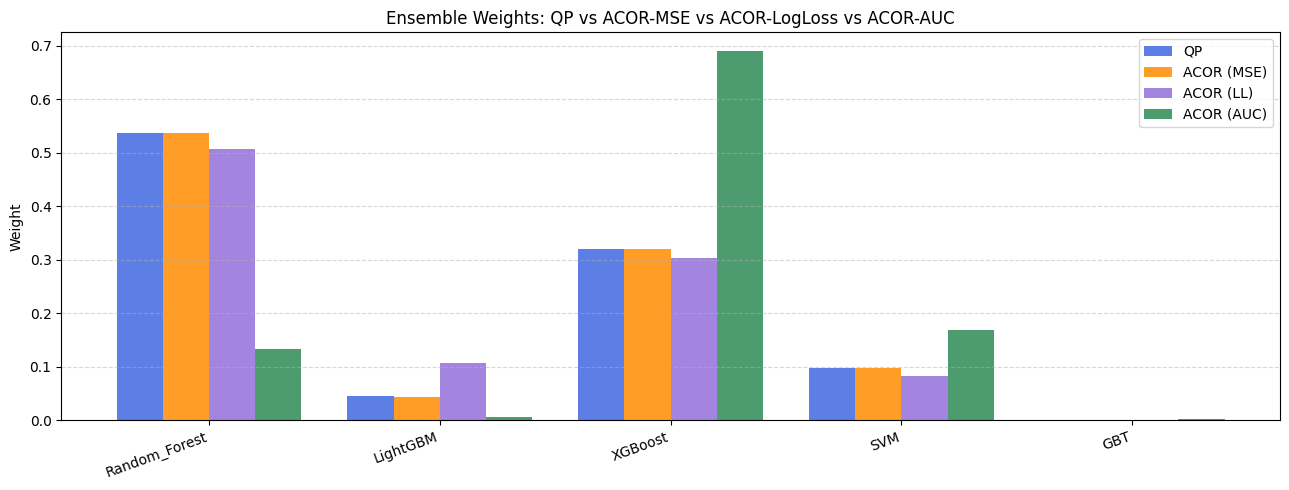

In [48]:
x = np.arange(M)
w_bar = 0.2
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 1.5*w_bar, w_QP,      width=w_bar, label='QP',         color='royalblue',  alpha=0.85)
ax.bar(x - 0.5*w_bar, w_ACO_mse, width=w_bar, label='ACOR (MSE)', color='darkorange',  alpha=0.85)
ax.bar(x + 0.5*w_bar, w_ACO_ll,  width=w_bar, label='ACOR (LL)',  color='mediumpurple',alpha=0.85)
ax.bar(x + 1.5*w_bar, w_ACO_auc, width=w_bar, label='ACOR (AUC)', color='seagreen',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(selected_names, rotation=20, ha='right')
ax.set_ylabel('Weight'); ax.set_title('Ensemble Weights: QP vs ACOR-MSE vs ACOR-LogLoss vs ACOR-AUC')
ax.legend(); ax.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 9  Final Test-Set Evaluation

We compare **four ensemble strategies** on the untouched held-out test set:

| Strategy | Weights |
|---|---|
| Simple average | 1/M for all models |
| QP optimal | SLSQP exact solution |
| ACOR (MSE) | ACOR minimising MSE on validation |
| ACOR (AUC) | ACOR maximising AUC on validation |

In [49]:
def evaluate(name, probs, y_true, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    auc  = roc_auc_score(y_true, probs)
    prec = precision_score(y_true, preds, zero_division=0)
    rec  = recall_score(y_true, preds, zero_division=0)
    f1   = f1_score(y_true, preds, zero_division=0)
    ll   = log_loss(y_true, np.clip(probs, 1e-7, 1-1e-7))
    cm   = confusion_matrix(y_true, preds)
    return {'name': name, 'AUC': auc, 'LogLoss': ll, 'Precision': prec,
            'Recall': rec, 'F1': f1,
            'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0], 'TP': cm[1,1]}

w_uniform = np.ones(M) / M

results = [
    evaluate('Simple Average',   P_test @ w_uniform,  y_test_arr),
    evaluate('QP Optimal',        P_test @ w_QP,       y_test_arr),
    evaluate('ACOR (MSE obj)',    P_test @ w_ACO_mse,  y_test_arr),
    evaluate('ACOR (LogLoss obj)',P_test @ w_ACO_ll,   y_test_arr),
    evaluate('ACOR (AUC obj)',    P_test @ w_ACO_auc,  y_test_arr),
]

print('\n' + '='*76)
print('FINAL TEST RESULTS')
print('='*76)
header = f'{"Strategy":<24} | {"AUC":>6} | {"LogLoss":>7} | {"Prec":>6} | {"Rec":>6} | {"F1":>6}'
print(header)
print('-'*76)
for r in results:
    print(f'{r["name"]:<24} | {r["AUC"]:>6.4f} | {r["LogLoss"]:>7.4f} | '
          f'{r["Precision"]:>6.4f} | {r["Recall"]:>6.4f} | {r["F1"]:>6.4f}')
print('='*76)

# ── Individual model baselines ──
print('\n--- Individual base model baselines ---')
for i, name in enumerate(selected_names):
    r = evaluate(name, P_test[:, i], y_test_arr)
    print(f'{name:<22}  AUC={r["AUC"]:.4f}  LogLoss={r["LogLoss"]:.4f}  F1={r["F1"]:.4f}')


FINAL TEST RESULTS
Strategy                 |    AUC | LogLoss |   Prec |    Rec |     F1
----------------------------------------------------------------------------
Simple Average           | 0.7507 |  0.5496 | 0.5312 | 0.5667 | 0.5484
QP Optimal               | 0.7462 |  0.5471 | 0.5231 | 0.5667 | 0.5440
ACOR (MSE obj)           | 0.7462 |  0.5471 | 0.5231 | 0.5667 | 0.5440
ACOR (LogLoss obj)       | 0.7473 |  0.5464 | 0.5231 | 0.5667 | 0.5440
ACOR (AUC obj)           | 0.7562 |  0.5483 | 0.5373 | 0.6000 | 0.5669

--- Individual base model baselines ---
Random_Forest           AUC=0.7107  LogLoss=0.5686  F1=0.4640
LightGBM                AUC=0.7551  LogLoss=0.5686  F1=0.5512
XGBoost                 AUC=0.7510  LogLoss=0.5673  F1=0.5528
SVM                     AUC=0.7530  LogLoss=0.5793  F1=0.5426
GBT                     AUC=0.7265  LogLoss=0.6172  F1=0.5167


## 10  Summary & Takeaways

- **Model Selection**: OOF AUC ranking objectively identifies the best `k` models, preventing weak/correlated models from diluting the ensemble.
- **ACOR (MSE)** should closely match the QP solution, confirming the metaheuristic converges to the global optimum for this smooth objective.
- **ACOR (AUC)** often yields *better* test AUC than the MSE-based approaches because it optimises the metric that matters — ranking quality — directly on the validation set.
- The architecture is **metric-agnostic**: swap `objective='auc'` for any callable loss (e.g. cost-sensitive F1, Kolmogorov–Smirnov statistic) without changing the solver.

### ACOR Hyper-parameter Tuning Guide
| Want more exploration? | ↑ `q`, ↑ `n_ants`, ↑ `iterations` |
|---|---|
| Want faster exploitation? | ↓ `q`, ↑ `xi` (closer to 1) |
| Noisy objective? | ↑ `archive_size` for more diverse memory |